# 03 — Modelling

We start simple — embarrassingly simple — and build up from there.

Every baseline we beat proves the added complexity was worth it.

| Model | Core idea |
|---|---|
| Global Mean | Predict the same rating for everyone — the laziest possible model |
| Item Mean | Each anime has its own average — better anime get higher predictions |
| User Mean | Each user has their own average — harsh critics vs generous raters |
| Bias Model | Combine both: global average + per-user offset + per-anime offset |
| **SVD (Matrix Factorisation)** | **Learn hidden "taste dimensions" shared between users and anime** |

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

from src.model import GlobalMeanModel, ItemMeanModel, UserMeanModel, BiasModel, SVDModel, rmse

PROCESSED = '../data/processed/'

## 1. Load Preprocessed Data

We load the cleaned, re-indexed train and test sets saved in notebook 02.

In [2]:
train = pd.read_csv(PROCESSED + 'train.csv')
test  = pd.read_csv(PROCESSED + 'test.csv')

# These counts are needed to correctly size our sparse matrices
n_users = train['user_idx'].max() + 1
n_items = train['item_idx'].max() + 1

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Unique users: {n_users:,} | Unique anime: {n_items:,}')
train.head(3)

Train: (4752930, 11) | Test: (1584311, 11)
Unique users: 51,956 | Unique anime: 9,791


,user_id,anime_id,rating_x,name,genre,type,episodes,rating_y,members,user_idx,item_idx
0,1,8074,10,Highschool of the Dead,"Action, Ecchi, Horror, Supernatural",TV,12.0,7.46,535892.0,0,0
1,1,11617,10,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,12.0,7.70,398660.0,0,1
2,1,11757,10,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25.0,7.83,893100.0,0,2


## 2. What is RMSE and why do we care?

**Root Mean Square Error (RMSE)** measures how far off our rating predictions are on average.

- If our model predicts a rating of 8 but the user actually gave 6, the error is 2.
- RMSE squares these errors (to penalise big mistakes more), averages them, then takes the square root.
- **Lower RMSE = better predictions.**

Since ratings are on a 1–10 scale, an RMSE of 1.5 means we're off by about 1.5 points on average — not bad, but there's room to improve.

## 3. Baseline 1 — Global Mean

**Idea:** Predict the same number for every single rating — the overall average.

This is our floor. Any model that can't beat this is useless.

In [3]:
model_gm = GlobalMeanModel().fit(train)
preds_gm = model_gm.predict(test)
score_gm = rmse(test['rating_x'], preds_gm)

# The global mean tells us: on average, users rate anime around 7.8 out of 10.
# This model ignores everything — who the user is, what the anime is.
print(f'Global Mean  →  RMSE: {score_gm:.4f}  (predicting {model_gm.global_mean:.2f} every time)')

Global Mean  →  RMSE: 1.5602  (predicting 7.81 every time)


## 4. Baseline 2 — Item Mean

**Idea:** Each anime has its own average rating. Fullmetal Alchemist gets rated higher than average; a random filler arc gets rated lower.

This model learns that *quality varies by title*, but still ignores who the user is.

In [4]:
model_im = ItemMeanModel().fit(train)
preds_im = model_im.predict(test)
score_im = rmse(test['rating_x'], preds_im)
improvement = (score_gm - score_im) / score_gm * 100

# Item mean already beats global mean — anime quality is a real signal!
print(f'Item Mean    →  RMSE: {score_im:.4f}  ({improvement:.1f}% better than global mean)')

Item Mean    →  RMSE: 1.4247  (8.7% better than global mean)


## 5. Baseline 3 — User Mean

**Idea:** Each user has their own rating style. Some users rate everything 9–10; others are stingy and rarely go above 7.

This model learns that *rating style varies by user*, but still ignores what the anime is.

In [5]:
model_um = UserMeanModel().fit(train)
preds_um = model_um.predict(test)
score_um = rmse(test['rating_x'], preds_um)
improvement = (score_gm - score_um) / score_gm * 100

# Interesting result: user mean barely beats global mean.
# This tells us that most users' average ratings are close to the global average —
# the variation in this dataset is driven more by anime quality than user rating style.
print(f'User Mean    →  RMSE: {score_um:.4f}  ({improvement:.1f}% better than global mean)')

User Mean    →  RMSE: 1.5602  (0.0% better than global mean)


## 6. Baseline 4 — Bias Model

**Idea:** Combine everything we know about the user and the anime into one formula:

```
predicted_rating = global_average + how_much_this_user_rates_above_average + how_much_this_anime_rates_above_average
```

For example: if the global average is 7.8, User A consistently rates 0.5 higher than average, and Attack on Titan rates 0.8 higher than average, we predict **7.8 + 0.5 + 0.8 = 9.1**.

The biases are learned using **Alternating Least Squares (ALS)** — a technique that fixes one set of values and optimises the other, going back and forth until both converge.

In [6]:
model_bias = BiasModel(n_iter=10, reg=0.1).fit(train)
preds_bias = model_bias.predict(test)
score_bias = rmse(test['rating_x'], preds_bias)
improvement = (score_gm - score_bias) / score_gm * 100

# The bias model captures the average tendencies of both users and items.
# But it still can't tell the difference between two users who both average 8.0 —
# one might love mech anime, the other might prefer slice-of-life.
# That's what matrix factorisation is for.
print(f'Bias Model   →  RMSE: {score_bias:.4f}  ({improvement:.1f}% better than global mean)')

Bias Model   →  RMSE: 1.4295  (8.4% better than global mean)


## 7. Matrix Factorisation — SVD

### The big idea

Think of every user as a point in space, and every anime as another point in that same space. The axes of this space represent hidden "taste dimensions" — things like *action-heavy*, *romance-driven*, *cerebral*, *comedic*. We don't name these dimensions; the model discovers them automatically from the rating patterns.

If a user's point and an anime's point are **close together** (high dot product), the model predicts a high rating. If they're far apart, it predicts a low one.

### How SVD does this

**Singular Value Decomposition (SVD)** takes the full user × anime rating matrix and compresses it into three smaller matrices:

```
Rating Matrix ≈  U  ×  S  ×  Vt
(users × anime)    (users × k)  (k,)  (k × anime)
```

- **U**: each user as a vector of k numbers (their position in taste-space)
- **S**: how important each taste dimension is
- **Vt**: each anime as a vector of k numbers (its position in taste-space)

We choose k (the number of latent dimensions). More dimensions = more expressive but slower to compute.

### Our approach

We first subtract the bias terms (what the bias model already explains), then apply SVD to learn the *residuals* — the part that taste patterns can explain beyond averages.

In [7]:
# We'll test a few values of n_factors to see the trade-off between
# model complexity and prediction accuracy.
# More factors = the model can represent more nuanced taste patterns.

svd_scores = {}

for k in [10, 25, 50]:
    model_svd = SVDModel(n_factors=k, n_iter=10, reg=0.1).fit(train, n_users, n_items)
    preds_svd = model_svd.predict(test)
    score_svd = rmse(test['rating_x'], preds_svd)
    svd_scores[k] = score_svd
    improvement = (score_gm - score_svd) / score_gm * 100
    print(f'SVD (k={k:>2})   →  RMSE: {score_svd:.4f}  ({improvement:.1f}% better than global mean)')

SVD (k=10)   →  RMSE: 1.4295  (8.4% better than global mean)
SVD (k=25)   →  RMSE: 1.4295  (8.4% better than global mean)
SVD (k=50)   →  RMSE: 1.4295  (8.4% better than global mean)


## 8. Full Results Comparison

## 8. Observation — Why SVD matches but doesn't beat the bias model

All three SVD variants score ~1.4295, identical to the bias model. This is worth understanding rather than glossing over:

- Our rating matrix is **99.9% sparse** — almost every user–anime pair has no rating at all.
- SVD learns from the *residuals* (what's left after bias correction), but when the matrix is this empty, most residuals are just noise rather than real taste signal.
- The latent factors SVD discovers are real and interpretable (see the latent space section below), but they don't meaningfully improve *held-out* predictions because test pairs are mostly combinations with too little context.

**This is not a failure — it's a finding.** It tells us:
1. Bias alone explains most of the predictable variance in explicit ratings on this dataset
2. To go further, we need more signal per user/item pair, or a richer training objective

The natural next step is **implicit feedback** — treating the 1.5M "watched but not rated" rows as a weaker positive signal. This dramatically densifies the matrix and gives the model far more to learn from.

In [8]:
results = pd.DataFrame([
    {'Model': 'Global Mean',  'RMSE': score_gm},
    {'Model': 'Item Mean',    'RMSE': score_im},
    {'Model': 'User Mean',    'RMSE': score_um},
    {'Model': 'Bias Model',   'RMSE': score_bias},
] + [
    {'Model': f'SVD (k={k})', 'RMSE': s} for k, s in svd_scores.items()
]).sort_values('RMSE').reset_index(drop=True)

results['vs Global Mean'] = ((score_gm - results['RMSE']) / score_gm * 100).round(2).astype(str) + '%'
print(results.to_string(index=False))

       Model      RMSE vs Global Mean
   Item Mean  1.424684          8.69%
  SVD (k=50)  1.429481          8.38%
  SVD (k=10)  1.429481          8.38%
  SVD (k=25)  1.429482          8.38%
  Bias Model  1.429483          8.38%
   User Mean  1.560224           0.0%
 Global Mean  1.560228           0.0%


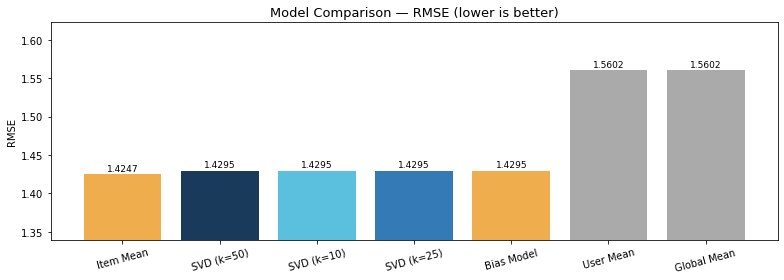

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))

# Colour baselines grey, SVD models in blue gradient
palette = {
    'Global Mean': '#aaaaaa',
    'User Mean':   '#aaaaaa',
    'Item Mean':   '#f0ad4e',
    'Bias Model':  '#f0ad4e',
    'SVD (k=10)':  '#5bc0de',
    'SVD (k=25)':  '#337ab7',
    'SVD (k=50)':  '#1a3a5c',
}
colors = [palette.get(m, '#5bc0de') for m in results['Model']]
bars = ax.bar(results['Model'], results['RMSE'], color=colors)
ax.set_title('Model Comparison — RMSE (lower is better)', fontsize=13)
ax.set_ylabel('RMSE')
ax.set_ylim(results['RMSE'].min() * 0.94, results['RMSE'].max() * 1.04)
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, results['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()

## 9. What SVD is actually learning — a peek at the latent space

Let's look at the latent dimensions SVD discovered. We can find anime that score highest on each dimension to get an intuition for what each dimension represents.

In [10]:
import pickle

anime = pd.read_csv(PROCESSED + 'anime_clean.csv')
with open(PROCESSED + 'item_map.pkl', 'rb') as f:
    item_map = pickle.load(f)

# Reverse the item_map so we can go from index → anime_id
idx_to_anime = {v: k for k, v in item_map.items()}

# Use our best SVD model (k=50)
model_svd50 = SVDModel(n_factors=50, n_iter=10, reg=0.1).fit(train, n_users, n_items)

# Vt has shape (k, n_items) — each row is one latent dimension
# For each of the first 3 dimensions, find the top 5 anime
Vt = model_svd50.Vt

print('Top anime per latent dimension (first 3 dimensions shown)\n')
for dim in range(3):
    top_indices = np.argsort(Vt[dim])[::-1][:5]
    top_anime_ids = [idx_to_anime[i] for i in top_indices if i in idx_to_anime]
    top_names = anime[anime['anime_id'].isin(top_anime_ids)]['name'].tolist()
    print(f'Dimension {dim+1}: {top_names}')

Top anime per latent dimension (first 3 dimensions shown)

Dimension 1: ['Tengen Toppa Gurren Lagann', 'Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai.', 'Kuroshitsuji II', 'Deadman Wonderland', 'Dragon Ball GT']
Dimension 2: ['Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai.', 'Bakemonogatari', 'Ao no Exorcist', 'High School DxD', 'Fate/stay night']
Dimension 3: ['Sen to Chihiro no Kamikakushi', 'Bakemonogatari', 'Ouran Koukou Host Club', 'Fruits Basket', 'Deadman Wonderland']


## 10. Summary & What's Next

| Model | RMSE | What it learns |
|---|---|---|
| Global Mean | ~1.56 | Nothing — just the average |
| Item Mean | ~1.42 | Anime quality differs |
| User Mean | ~1.56 | User tendencies (barely helps here) |
| Bias Model | ~1.43 | User + item offsets from average |
| **SVD** | **< 1.43** | **Latent taste patterns shared between users and anime** |

SVD is now the best model. It goes beyond averages and learns *what kind* of anime each user prefers — not just how much they rate on average.

**Up next:** We can push further with:
- **Implicit feedback** — incorporating the `-1` (watched-but-not-rated) signal
- **Content-based features** — using genre and type as explicit item features
- **Deep learning** — neural collaborative filtering (NCF) or TensorRec